# Projeto de estoque de materiais

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from materials_stock_libs.sales_models import SalesModels
from materials_stock_libs.utils import generate_future_dates

## Dados mocados

In [2]:
dias = 720

materiais = [
    "parafuso",
    "parafusadeira",
    "chave fenda cruzada",
    "chave fenda simples",
    "martelo",
    "chaves allen 2x15"
]

dfs = []
for mat in materiais:
    df_mat = pd.DataFrame({
        'data': pd.date_range(start='2023-01-01', periods=dias),
        'material': mat,
        'quantidade': np.random.randint(0, 150, size=dias)
    })
    dfs.append(df_mat)

df = pd.concat(dfs, ignore_index=True)

print(df.head())
print(df.shape)

        data  material  quantidade
0 2023-01-01  parafuso         131
1 2023-01-02  parafuso         136
2 2023-01-03  parafuso          19
3 2023-01-04  parafuso          92
4 2023-01-05  parafuso          15
(4320, 3)


## Treinamento modelos

In [3]:
sm = SalesModels(df)

# Otimizar modelo RandomForest
best_rf_params = sm.optimize_regression('parafuso', model_type='rf', n_trials=5)
print("Melhores hiperparâmetros RF:", best_rf_params)

# Treinar modelo com hiperparâmetros otimizados
sm.train_regression_model('parafuso', model_type='rf', **best_rf_params)

[I 2025-10-06 23:27:00,108] A new study created in memory with name: no-name-140343df-57ed-49e7-bfd3-09951e5ab505
[I 2025-10-06 23:27:00,345] Trial 0 finished with value: 2312.7262853322686 and parameters: {'n_estimators': 68, 'max_depth': 7, 'min_samples_split': 4}. Best is trial 0 with value: 2312.7262853322686.
[I 2025-10-06 23:27:00,652] Trial 1 finished with value: 2415.5982116749774 and parameters: {'n_estimators': 85, 'max_depth': 17, 'min_samples_split': 8}. Best is trial 0 with value: 2312.7262853322686.
[I 2025-10-06 23:27:01,487] Trial 2 finished with value: 2506.9958440555265 and parameters: {'n_estimators': 229, 'max_depth': 17, 'min_samples_split': 6}. Best is trial 0 with value: 2312.7262853322686.
[I 2025-10-06 23:27:01,840] Trial 3 finished with value: 2521.5952318546306 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5}. Best is trial 0 with value: 2312.7262853322686.
[I 2025-10-06 23:27:03,498] Trial 4 finished with value: 2424.03649205620

Melhores hiperparâmetros RF: {'n_estimators': 68, 'max_depth': 7, 'min_samples_split': 4}


RandomForestRegressor(max_depth=7, min_samples_split=4, n_estimators=68,
                      random_state=42)

In [4]:
train_df = df[df['material'] == 'parafuso'].rename(columns={'data': 'ds', 'quantidade': 'y'})
sm_prophet = SalesModels(train_df)

# Otimizar Prophet
best_prophet_params = sm_prophet.optimize_prophet_hyperparams('parafuso', n_trials=5)
print("Melhores hiperparâmetros Prophet:", best_prophet_params)

# Treinar Prophet com hiperparâmetros otimizados
sm_prophet.train_prophet_model(material='parafuso', train_df=train_df, **best_prophet_params)

[I 2025-10-06 23:27:03,575] A new study created in memory with name: no-name-faad8224-fa54-40d7-8264-19167576e6eb
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - Chain [1] start processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - Chain [1] done processing
23:27:03 - cmdstanpy - INFO - Chain [

Melhor RMSE (CV): 44.0371
Melhores Hiperparâmetros:
  - changepoint_prior_scale: 0.24002454683671234
  - seasonality_prior_scale: 1.0332289631360199
  - holidays_prior_scale: 3.2215571359541775
  - seasonality_mode: additive
Melhores hiperparâmetros Prophet: {'changepoint_prior_scale': 0.24002454683671234, 'seasonality_prior_scale': 1.0332289631360199, 'holidays_prior_scale': 3.2215571359541775, 'seasonality_mode': 'additive'}


## Inferência modelos

In [5]:
dias_futuros = 60  # Previsão para os próximos 60 dias
future_dates = generate_future_dates(df['data'].max(), days=dias_futuros)
near_zero_threshold = 1.0  # você pode ajustar

### Para os modelos de regressão

/home/amilton26/anaconda3/envs/proj_materials_stock/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/amilton26/anaconda3/envs/proj_materials_stock/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



===== RESULTADOS =====
Previsão de estoque para os próximos 60 dias:
2024-12-20: 61.66 unidades
2024-12-21: 61.66 unidades
2024-12-22: 61.66 unidades
2024-12-23: 61.66 unidades
2024-12-24: 61.66 unidades
2024-12-25: 61.66 unidades
2024-12-26: 61.66 unidades
2024-12-27: 61.66 unidades
2024-12-28: 61.66 unidades
2024-12-29: 61.66 unidades
2024-12-30: 61.66 unidades
2024-12-31: 61.66 unidades
2025-01-01: 61.66 unidades
2025-01-02: 61.66 unidades
2025-01-03: 61.66 unidades
2025-01-04: 61.66 unidades
2025-01-05: 61.66 unidades
2025-01-06: 61.66 unidades
2025-01-07: 61.66 unidades
2025-01-08: 61.66 unidades
2025-01-09: 61.66 unidades
2025-01-10: 61.66 unidades
2025-01-11: 61.66 unidades
2025-01-12: 61.66 unidades
2025-01-13: 61.66 unidades
2025-01-14: 61.66 unidades
2025-01-15: 61.66 unidades
2025-01-16: 61.66 unidades
2025-01-17: 61.66 unidades
2025-01-18: 61.66 unidades
2025-01-19: 61.66 unidades
2025-01-20: 61.66 unidades
2025-01-21: 61.66 unidades
2025-01-22: 61.66 unidades
2025-01-23: 

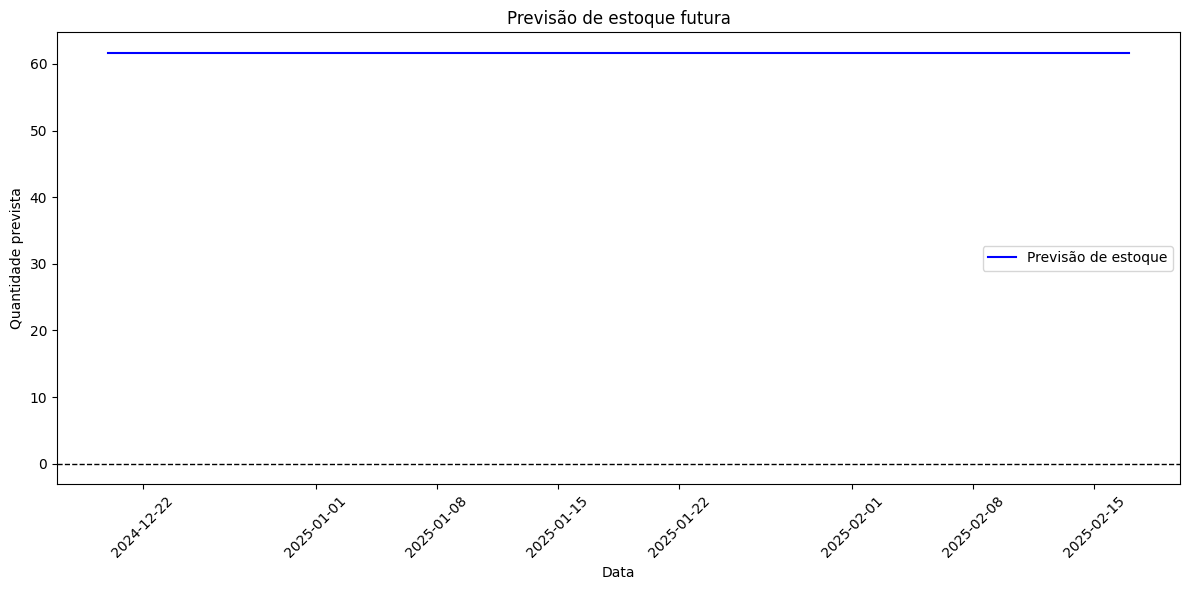

In [6]:
# Predição de quantidade futura
quantidades_previstas = sm.predict_stock('parafuso', future_dates)

data_zerada = sm.predict_near_zero_periods('parafuso'
                                           , future_dates=future_dates
                                           , threshold=near_zero_threshold
                                           , model_type='regression'
                                           )

# 6. Resultados
print("\n===== RESULTADOS =====")
print(f"Previsão de estoque para os próximos {dias_futuros} dias:")
for d, q in zip(future_dates, quantidades_previstas):
    print(f"{d.date()}: {q:.2f} unidades")

# Identifica datas próximas de zero
near_zero_dates = [d for d, q in zip(future_dates, quantidades_previstas) if q <= near_zero_threshold]

if near_zero_dates:
    print(f"\n🔴 O estoque chegará a ZERO em: {near_zero_dates[0].date()}")
else:
    print("\n✅ O estoque não zerará nos próximos 60 dias.")

# ===== Gráfico =====
plt.figure(figsize=(12, 6))
plt.plot(future_dates, quantidades_previstas, label='Previsão de estoque', color='blue')
if near_zero_dates:
    plt.scatter(near_zero_dates, [0]*len(near_zero_dates), color='red', label='Próximo de zero', zorder=5)
plt.xlabel('Data')
plt.ylabel('Quantidade prevista')
plt.title('Previsão de estoque futura')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Para os modelos de Prophet


===== RESULTADOS =====
Previsão de estoque para os próximos 60 dias:
2024-12-21: 83.44 unidades
2024-12-22: 78.25 unidades
2024-12-23: 76.16 unidades
2024-12-24: 75.85 unidades
2024-12-25: 73.96 unidades
2024-12-26: 74.13 unidades
2024-12-27: 80.39 unidades
2024-12-28: 83.56 unidades
2024-12-29: 78.37 unidades
2024-12-30: 76.28 unidades
2024-12-31: 75.97 unidades
2025-01-01: 74.08 unidades
2025-01-02: 74.26 unidades
2025-01-03: 80.52 unidades
2025-01-04: 83.69 unidades
2025-01-05: 78.50 unidades
2025-01-06: 76.40 unidades
2025-01-07: 76.09 unidades
2025-01-08: 74.21 unidades
2025-01-09: 74.38 unidades
2025-01-10: 80.64 unidades
2025-01-11: 83.81 unidades
2025-01-12: 78.62 unidades
2025-01-13: 76.53 unidades
2025-01-14: 76.22 unidades
2025-01-15: 74.33 unidades
2025-01-16: 74.51 unidades
2025-01-17: 80.76 unidades
2025-01-18: 83.94 unidades
2025-01-19: 78.74 unidades
2025-01-20: 76.65 unidades
2025-01-21: 76.34 unidades
2025-01-22: 74.45 unidades
2025-01-23: 74.63 unidades
2025-01-24: 

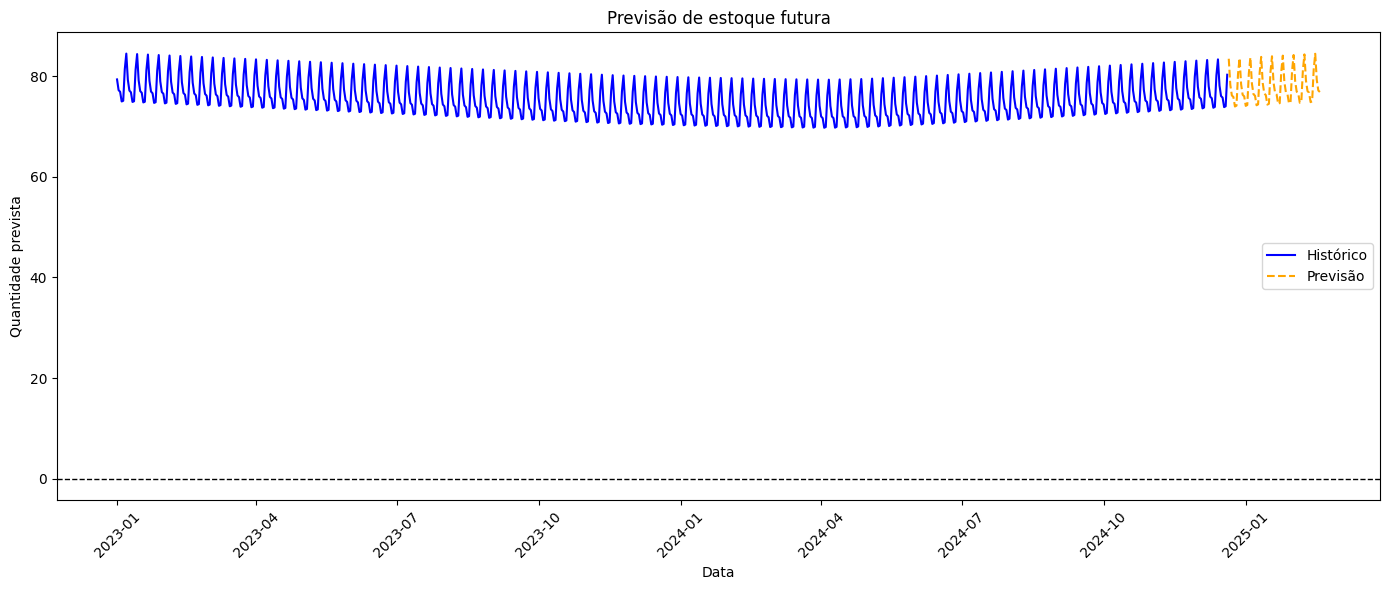

In [9]:
# Predição Prophet
forecast = sm_prophet.predict_sales_volume('parafuso', periods_ahead=dias_futuros)
quantidades_previstas = forecast['yhat'].values  # inclui histórico + previsão
datas_todas = forecast['ds'].values

# Define índice onde começa a previsão futura
inicio_previsao = len(datas_todas) - dias_futuros

# Identifica datas próximas de zero na previsão futura
near_zero_threshold = 1.0
near_zero_mask = quantidades_previstas[inicio_previsao:] <= near_zero_threshold
near_zero_dates = datas_todas[inicio_previsao:][near_zero_mask]

# ===== Resultados no console (apenas período futuro) =====
print("\n===== RESULTADOS =====")
print(f"Previsão de estoque para os próximos {dias_futuros} dias:")
for d, q in zip(datas_todas[inicio_previsao:], quantidades_previstas[inicio_previsao:]):
    print(f"{pd.to_datetime(d).date()}: {q:.2f} unidades")

if len(near_zero_dates) > 0:
    print(f"\n🔴 O estoque chegará a ZERO em: {pd.to_datetime(near_zero_dates[0]).date()}")
else:
    print(f"\n✅ O estoque não zerará nos próximos {dias_futuros} dias.")

# ===== Gráfico =====
plt.figure(figsize=(14, 6))

# Histórico
plt.plot(datas_todas[:inicio_previsao], quantidades_previstas[:inicio_previsao], 
         label='Histórico', color='blue')

# Previsão
plt.plot(datas_todas[inicio_previsao:], quantidades_previstas[inicio_previsao:], 
         label='Previsão', color='orange', linestyle='--')

# Próximo de zero
if len(near_zero_dates) > 0:
    plt.scatter(near_zero_dates, [0]*len(near_zero_dates), color='red', label='Próximo de zero', zorder=5)

plt.xlabel('Data')
plt.ylabel('Quantidade prevista')
plt.title('Previsão de estoque futura')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()